# Инференс финальной модели

В данном ноутбуке демонстрируется использование обученной модели ResNet18 (с Label Smoothing — финальная конфигурация по итогам `03_model_tuning.ipynb`) для предсказания заболеваний листьев кукурузы на отдельных изображениях.

## Цели

- загрузить сохранённую модель;
- выполнить инференс на отдельных изображениях;
- вывести вероятности всех классов;
- визуализировать результаты предсказания;
- проверить модель на случайных примерах из тестовой выборки и оценить ошибки.

## Импорты

In [13]:
import sys
import os

# Путь к корневой папке проекта (на уровень выше)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Добавить в sys.path
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [14]:
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from src.models import create_model


## Конфигурация

In [15]:
DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

MODEL_PATH  = "../artifacts/best_model.pt"
CONFIG_PATH = "../artifacts/config.json"
TEST_SPLIT_PATH = "../splits/test.csv"

print("Device:", DEVICE)


Device: cpu


## Загрузка модели

In [16]:
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = json.load(f)

class_names = config["class_names"]

if isinstance(class_names, dict):
    class_names = list(class_names.values())

model = create_model(
    num_classes=len(class_names),
    pretrained=False,
)

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE,
    )
)

model.to(DEVICE)
model.eval()

print("Модель загружена")
print("Классы:", class_names)


Модель загружена
Классы: ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']


## Преобразования изображения

In [17]:
# Идентичны препроцессингу val/test выборки в обучающих ноутбуках —
# модель должна получать на инференсе те же по структуре данные,
# на которых она валидировалась во время обучения
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


## Функция предсказания

In [18]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    tensor = (
        transform(image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.no_grad():

        logits = model(tensor)

        probs = torch.softmax(
            logits,
            dim=1,
        )

    probs = probs[0].cpu().numpy()

    pred_idx = probs.argmax()

    return (
        image,
        class_names[pred_idx],
        probs,
    )


## Визуализация результата

In [19]:
def show_prediction(image_path):

    image, pred_class, probs = predict_image(
        image_path
    )

    plt.figure(figsize=(8, 6))

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Предсказание: {pred_class}"
    )

    plt.show()

    print("\nВероятности классов:\n")

    for cls, prob in zip(
        class_names,
        probs,
    ):
        print(
            f"{cls:20s} {prob:.4f}"
        )


## Случайное изображение из датасета

Случайным образом выбирается класс и изображение из датасета.

Выбранный класс: Gray_Leaf_Spot
Файл: ..\data\data\Gray_Leaf_Spot\Corn_Gray_Spot (75).jpg


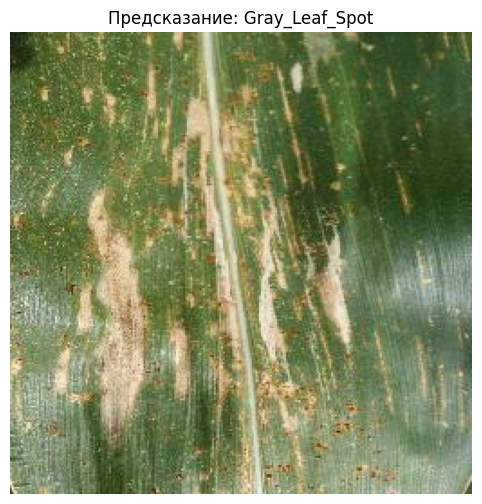


Вероятности классов:

Blight               0.0217
Common_Rust          0.0241
Gray_Leaf_Spot       0.9340
Healthy              0.0202


In [20]:
from pathlib import Path
import random

DATA_DIR = Path('../data/data')

classes = [
    'Blight',
    'Common_Rust',
    'Gray_Leaf_Spot',
    'Healthy',
]

selected_class = random.choice(classes)
image_path = random.choice(list((DATA_DIR / selected_class).glob('*')))

print('Выбранный класс:', selected_class)
print('Файл:', image_path)

show_prediction(str(image_path))

## По одному случайному изображению из каждого класса

Класс: Blight


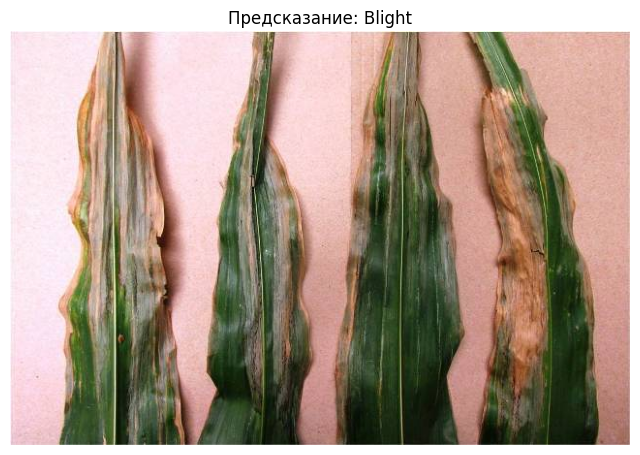


Вероятности классов:

Blight               0.9388
Common_Rust          0.0255
Gray_Leaf_Spot       0.0131
Healthy              0.0226
Класс: Common_Rust


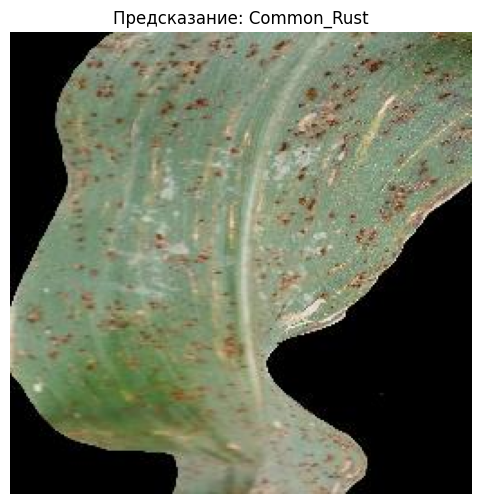


Вероятности классов:

Blight               0.0225
Common_Rust          0.9261
Gray_Leaf_Spot       0.0226
Healthy              0.0288
Класс: Gray_Leaf_Spot


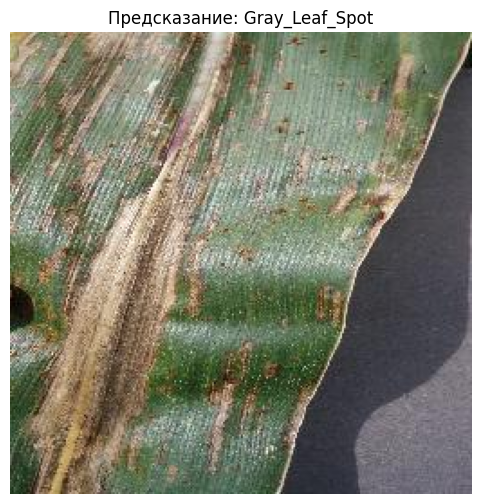


Вероятности классов:

Blight               0.0145
Common_Rust          0.0130
Gray_Leaf_Spot       0.9593
Healthy              0.0132
Класс: Healthy


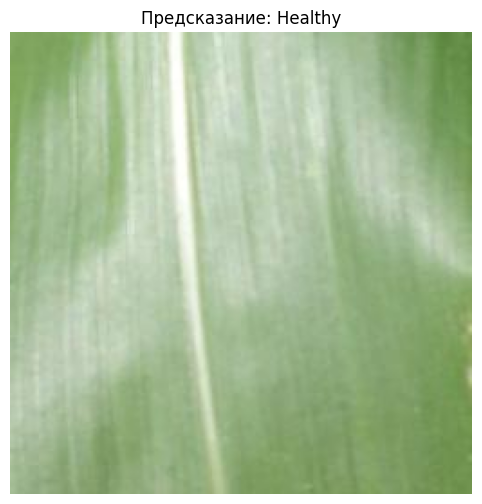


Вероятности классов:

Blight               0.0244
Common_Rust          0.0206
Gray_Leaf_Spot       0.0179
Healthy              0.9371


In [21]:
from pathlib import Path
import random

DATA_DIR = Path('../data/data')

classes = [
    'Blight',
    'Common_Rust',
    'Gray_Leaf_Spot',
    'Healthy',
]

for class_name in classes:
    files = list((DATA_DIR / class_name).glob('*'))
    image_path = random.choice(files)

    print('=' * 70)
    print('Класс:', class_name)

    show_prediction(str(image_path))

## Выводы

- Загружена обученная модель ResNet18.
- Выполнен инференс на отдельных изображениях.
- Получены вероятности для всех классов.
- Продемонстрирована работа модели на случайных изображениях датасета.
- Ноутбук предназначен для демонстрации модели, а не для оценки качества на тестовой выборке.
